In [1]:
import os
import re
import random
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

sys.path.append('/home/sam/Halo_Finder/Final_design/base_script')
from config_io import load_multifield_from_disk
from experiment import build_bg_only_cfg
from bg_stage import run_bg_inference, train_bg_only


def _global_fft_err(x_true, x_hat, n_slices=32):
    """Global FFT magnitude / phase L1 error over a strided set of z-slices."""
    x_true = np.asarray(x_true); x_hat = np.asarray(x_hat)
    D = x_true.shape[0]; step = max(1, D // int(n_slices))
    mag, pha = [], []
    for z in range(0, D, step):
        ft_t = np.fft.rfft2(x_true[z].astype(np.float64), norm="ortho")
        ft_h = np.fft.rfft2(x_hat[z].astype(np.float64), norm="ortho")
        mag.append(float(np.mean(np.abs(np.abs(ft_h) - np.abs(ft_t)))))
        d = np.angle(np.exp(1j * (np.angle(ft_h) - np.angle(ft_t))))
        pha.append(float(np.mean(np.abs(d))))
    return (float(np.mean(mag)) if mag else float("nan"),
            float(np.mean(pha)) if pha else float("nan"))


def _global_diag(x_true, x_hat):
    """Global reconstruction metrics (replaces the old ROI diagnostics)."""
    x_true = np.asarray(x_true); x_hat = np.asarray(x_hat)
    dr = float(x_true.max() - x_true.min()) or 1.0
    mse = float(np.mean((x_true - x_hat) ** 2))
    psnr = 20 * np.log10(dr) - 10 * np.log10(mse + 1e-12) if mse > 0 else 100.0
    max_err = float(np.max(np.abs(x_true - x_hat)))
    fm, fp = _global_fft_err(x_true, x_hat)
    return {"psnr": psnr, "max_err": max_err, "fft_mag_err": fm, "fft_phase_err": fp}

pysz_path = r"/home/sam/Data_Compression/SZ3/tools/pysz"
if pysz_path not in sys.path:
    sys.path.append(pysz_path)
from pysz import SZ


def set_seed(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


SEED = 42   # shared seed: NeurLZ + BG pipeline use the same SEED
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("device:", device)



device: cuda:0


In [2]:
# ==== 路径与数据（可按需改 TARGET_STEM / REL_SETTINGS）====
import sys
from pathlib import Path

base_path = Path(r"/home/sam/Halo_Finder/halo_finder_v1/SDRBENCH-EXASKY-NYX-512x512x512/origin").resolve()
base_path = base_path.as_posix() + "/"
sz_lib_path = r"/home/sam/Data_Compression/SZ3/build/lib64/libSZ3c.so"
data_shape = (512, 512, 512)

TARGET_STEM = "temperature"
FIELD_FILES = [
    "dark_matter_density.f32",
    # "temperature.f32",
    "velocity_x.f32",
    "velocity_y.f32",
    "velocity_z.f32",
]# temperature

REL_SETTINGS = [("r0", 1e-4), ("r1", 2e-4), ("r2", 3e-4),("r3", 4e-4),("r4", 5e-4),("r5", 6e-4),("r6", 7e-4)]
REL_ACTIVE_IDX = 0
REL_ERR_SZ_BITSTREAM = REL_SETTINGS[REL_ACTIVE_IDX][1]


def rel_sz_suffix(rel_err: float) -> str:
    return f"{rel_err:.0e}".replace("+", "")


def sz_bin_for_target(fname: str, rel_err: float) -> str:
    stem = Path(fname).stem
    return base_path + stem + "_rel" + rel_sz_suffix(rel_err) + ".sz"

fname = TARGET_STEM + ".f32"
gt_path = base_path + fname
aux_paths = [base_path + f for f in FIELD_FILES if f != fname]
sz_bin_path = sz_bin_for_target(fname, REL_ERR_SZ_BITSTREAM)

_sz_path = Path(sz_bin_path)
if not _sz_path.is_file():
    from pysz import SZ
    print("[save .sz] 压缩:", _sz_path)
    eng = SZ(sz_lib_path)
    vol = np.fromfile(gt_path, dtype=np.float32).reshape(data_shape)
    blob, cr = eng.compress(vol, 1, 0, REL_ERR_SZ_BITSTREAM, 0)
    del vol
    _sz_path.parent.mkdir(parents=True, exist_ok=True)
    _sz_path.write_bytes(blob)
    print("CR ≈", float(cr))

Xs, Xps = load_multifield_from_disk(
    gt_path=gt_path,
    aux_paths=aux_paths,
    sz_bin_path=sz_bin_path,
    data_shape=data_shape,
    pysz_path=pysz_path,
    sz_lib_path=sz_lib_path,
)
print("Loaded", TARGET_STEM, "| fields", len(Xs))

# (ROI removed -- global metrics only)

sz = SZ(sz_lib_path)
gt_target = np.asarray(Xs[0], np.float32)
aux_fields = [np.asarray(f, np.float32) for f in Xs[1:]]


def build_Xps_for_rel(rel_err: float):
    b, cr = sz.compress(gt_target, 1, 0, float(rel_err), 0)
    x_lq = sz.decompress(b, gt_target.shape, np.float32)
    return [x_lq] + aux_fields, float(cr), b

print("sanity CR:", build_Xps_for_rel(REL_SETTINGS[0][1])[1])



Loaded temperature | fields 5
sanity CR: 73.17323287426647


In [3]:
# ── NeurLZ baseline (LIVE) — SZ3 + monai BasicUNet, trained in-notebook ───────
# Replaces the CSV loader: per rel, train NeurLZ's BasicUNet on the SZ3 recon and
# append a results_compare entry with PSNR + FFT errors + correct CR
# (orig / (sz3_bytes + model params)). BasicUNet auto-sized to ~the BG model.
import io, contextlib
from monai.networks.nets import BasicUNet
from config_io import _error_bounded_post_process
from experiment import estimate_bg_model_param_bytes

ADD_NEURLZ        = False  # ignored for this ablation (frequency head / loss only)
NEURLZ_LR         = 1e-2
NEURLZ_BATCH      = 10
NEURLZ_MAX_PIXELS_PER_BATCH = 1024 * 1024   # cap batch*H*W so big slices don't OOM
NEURLZ_EPOCHS     = 100
NEURLZ_EVAL_EVERY = 4
NEURLZ_VERBOSE    = True
NEURLZ_FEATURES   = "match"   # "match" -> auto-size to the BG model's params; or a 6-tuple


def _bu_nparams(features):
    with contextlib.redirect_stdout(io.StringIO()):
        m = BasicUNet(spatial_dims=2, features=tuple(features), act="gelu",
                      in_channels=_nf_nlz, out_channels=1)
    n = sum(p.numel() for p in m.parameters() if p.requires_grad); del m
    return n

def _neurlz_features(target):
    if NEURLZ_FEATURES != "match":
        return tuple(NEURLZ_FEATURES)
    a, b, best = 4, 384, 4
    while a <= b:
        mid = (a + b) // 2
        if _bu_nparams((mid,) * 6) <= target: best = mid; a = mid + 1
        else: b = mid - 1
    hi = min(best + 1, 384)
    w = best if abs(_bu_nparams((best,)*6) - target) <= abs(_bu_nparams((hi,)*6) - target) else hi
    return (w,) * 6

def _mm_nlz(x, eps=1e-8):
    lo, hi = float(np.min(x)), float(np.max(x))
    return ((np.asarray(x, np.float32) - lo) / (hi - lo + eps)).astype(np.float32), (lo, hi)


def run_neurlz_live(rel_err, tag):
    Xps_rel, sz_ratio, sz_bytes = build_Xps_for_rel(float(rel_err))
    lq  = np.ascontiguousarray(Xps_rel[0], np.float32)
    tgt = np.asarray(gt_target, np.float32)
    fields = [lq] + [np.asarray(a, np.float32) for a in Xps_rel[1:]]
    D, H, W = tgt.shape
    lq_n = np.stack([_mm_nlz(f)[0] for f in fields], axis=1)
    err_n, (e_lo, e_hi) = _mm_nlz(tgt - lq)
    ph, pw = (-H) % 16, (-W) % 16
    pad = ((0, 0), (0, 0), (0, ph), (0, pw))
    Xlq = torch.from_numpy(np.pad(lq_n, pad, mode="reflect"))
    Yer = torch.from_numpy(np.pad(err_n[:, None], pad, mode="reflect"))
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    eff = max(1, min(NEURLZ_BATCH, NEURLZ_MAX_PIXELS_PER_BATCH // (H * W)))

    set_seed(SEED)
    with contextlib.redirect_stdout(io.StringIO()):
        model = BasicUNet(spatial_dims=2, features=tuple(NEURLZ_FEAT), act="gelu",
                          in_channels=len(fields), out_channels=1).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=NEURLZ_LR)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=1500)
    mse = torch.nn.MSELoss()
    idx = np.arange(D)

    def _recon():
        model.eval(); out = lq.copy()
        with torch.no_grad():
            for st in range(0, D, eff):
                bi = list(range(st, min(st + eff, D)))
                pr = model(Xlq[bi].to(device)).cpu().numpy()[:, 0, :H, :W]
                out[bi] = lq[bi] + (pr * (e_hi - e_lo + 1e-8) + e_lo)
        model.train()
        return _error_bounded_post_process(x_enhanced=out, x_prime=lq, absolute_error_bound=0.0,
                                           relative_error_bound=float(rel_err), verbose=False, a=1.0)

    hist = {"epoch": [], "loss": [], "psnr": [], "time": []}
    metric_log = []
    model.train()
    for ep in range(NEURLZ_EPOCHS):
        np.random.shuffle(idx); tot = nb = 0
        for st in range(0, D, eff):
            bi = idx[st:st + eff]
            loss = mse(model(Xlq[bi].to(device)), Yer[bi].to(device))
            opt.zero_grad(set_to_none=True); loss.backward(); opt.step(); sch.step()
            tot += float(loss.item()); nb += 1
        avg = tot / max(nb, 1)
        hist["epoch"].append(ep + 1); hist["loss"].append(avg); hist["time"].append(float("nan"))
        if (ep + 1) % NEURLZ_EVAL_EVERY == 0 or ep == NEURLZ_EPOCHS - 1:
            d = _global_diag(tgt, _recon())
            hist["psnr"].append((ep + 1, d["psnr"]))
            metric_log.append({**d, "epoch": ep + 1})
            if NEURLZ_VERBOSE:
                print(f"  [neurlz {tag} rel={rel_err:.0e}] ep {ep+1:3d}/{NEURLZ_EPOCHS} "
                      f"| MSE {avg:.6f} | PSNR {d['psnr']:.2f} dB | fftMag {d['fft_mag_err']:.3e}")
        elif NEURLZ_VERBOSE:
            print(f"  [neurlz {tag} rel={rel_err:.0e}] ep {ep+1:3d}/{NEURLZ_EPOCHS} | MSE {avg:.6f}")

    model_cpu = model.to("cpu"); del model
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    return {
        "name": f"NeurLZ [{TARGET_STEM}] rel={tag} [live]",
        "cfg": {"bg_arch": "neurlz_basicunet_live", "field": TARGET_STEM, "rel_err": float(rel_err)},
        "hist": hist, "metric_log": metric_log, "model": model_cpu,
        "rel_err": float(rel_err), "sz_ratio": float(sz_ratio),
        "sz3_bytes": int(len(sz_bytes)), "ablation_panel": None,
        "color": "tab:cyan", "marker": "X", "x_hat": None,
    }

if "results_compare" not in globals():
    results_compare = []
# Frequency head/loss ablation -> always drop any NeurLZ entries.
results_compare = [r for r in results_compare if "NeurLZ" not in str(r.get("name", ""))]
if ADD_NEURLZ:
    _aux_nlz     = globals().get("aux_fields", [])
    _nf_nlz      = 1 + len(_aux_nlz)
    _bg_h_nlz    = int(globals().get("DEFAULT_BG_H", 7))
    _bg_arch_nlz = str(globals().get("DEFAULT_BG_ARCH", "micro_film"))
    _bg_params_nlz, _ = estimate_bg_model_param_bytes(
        n_fields=_nf_nlz, shape=data_shape, bg_arch=_bg_arch_nlz, bg_h=_bg_h_nlz,
        bg_split_bands=True, bg_split_mode="three")
    NEURLZ_FEAT = _neurlz_features(_bg_params_nlz)
    print(f"[neurlz] BasicUNet features={NEURLZ_FEAT} (~{_bu_nparams(NEURLZ_FEAT):,} params) "
          f"~ BG model {_bg_params_nlz:,} | n_fields={_nf_nlz}")
    for tag, rel in REL_SETTINGS:
        results_compare.append(run_neurlz_live(rel, tag))
print("NeurLZ entries:", sum(1 for r in results_compare if "NeurLZ" in str(r.get("name", ""))))

/home/sam/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


NeurLZ entries: 0


In [4]:
import time
import re
from pathlib import Path

set_seed(SEED)

# 每次 train_bg_variant 结束后保存 checkpoint；改为 None 可关闭落盘
BG_CKPT_ROOT = None #Path("/home/sam/Halo_Finder/halo_finder_v1/scripts/ablation_ckpts")

BG_TRAIN_TIME = 10
BG_LR = 1e-3
BG_PATCH = 512
BG_BATCH = 1
MODEL_DTYPE_BYTES = 2

DEFAULT_BG_ARCH = "spatial"
DEFAULT_BG_H = 22
DEFAULT_BG_FIELD_NORM = "zscore"
DEFAULT_BG_FREQ_WEIGHT = 0.5
DEFAULT_BG_FFT_PHASE_WEIGHT = 0.5
DEFAULT_BG_FREQ_WARMUP = 1
DEFAULT_BG_SPLIT_MODE = "three"


def model_param_bytes(model, dtype_bytes=None):
    if model is None:
        return 0
    tot = 0
    for p in model.parameters():
        tot += p.numel() * (p.element_size() if dtype_bytes is None else int(dtype_bytes))
    return int(tot)


def psnr_np(x_true, x_hat):
    x_true = np.asarray(x_true, dtype=np.float64)
    x_hat = np.asarray(x_hat, dtype=np.float64)
    mse = float(np.mean((x_true - x_hat) ** 2))
    dr = float(np.max(x_true) - np.min(x_true))
    if mse <= 0:
        return float("inf")
    return float(20.0 * np.log10(max(dr, 1e-12) / np.sqrt(mse)))


def get_run_psnr(r, mode="best"):
    logs = r.get("metric_log", []) or []
    vals = [float(m["psnr"]) for m in logs if m.get("psnr") is not None and np.isfinite(float(m["psnr"]))]
    if vals:
        return float(max(vals) if mode == "best" else vals[-1])
    if r.get("x_hat") is not None:
        return psnr_np(Xs[0], r["x_hat"])
    return float("nan")


def patch_sz3_bytes(r):
    rel = float(r.get("rel_err", float("nan")))
    if not np.isfinite(rel):
        return
    sb = r.get("sz3_bytes", None)
    if sb is None or sb <= 0:
        _, _, b = build_Xps_for_rel(rel)
        r["sz3_bytes"] = int(len(b))
        r["sz_ratio"] = float(gt_target.nbytes / max(len(b), 1))


def _ablation_ckpt_slug(s, max_len=72):
    t = str(s).strip().replace(" ", "_")
    t = re.sub(r"[^\w.\-]+", "_", t)
    return t[:max_len] or "run"


def train_bg_variant(
    tag,
    rel_err,
    *,
    name,
    ablation_panel,
    ablation_tag,
    bg_field_norm=DEFAULT_BG_FIELD_NORM,
    bg_freq_weight=DEFAULT_BG_FREQ_WEIGHT,
    bg_fft_phase_weight=DEFAULT_BG_FFT_PHASE_WEIGHT,
    bg_freq_warmup_epochs=DEFAULT_BG_FREQ_WARMUP,
    bg_split_mode=DEFAULT_BG_SPLIT_MODE,
):
    Xps_rel, sz_ratio, sz_bytes = build_Xps_for_rel(float(rel_err))
    cfg = build_bg_only_cfg(
        X_target=Xs[0],
        Xps=Xps_rel,
        max_train_time=float(BG_TRAIN_TIME),
        bg_h=int(DEFAULT_BG_H),
        roi_h=4,
        epochs=20,
        steps_per_epoch=512,
        bg_patch_size=int(BG_PATCH),
        bg_batch=int(BG_BATCH),
        lr=float(BG_LR),
        bg_field_norm=str(bg_field_norm),
        bg_freq_weight=float(bg_freq_weight),
        bg_fft_phase_weight=float(bg_fft_phase_weight),
        bg_freq_warmup_epochs=int(bg_freq_warmup_epochs),
    )
    cfg.bg_arch = DEFAULT_BG_ARCH
    cfg.bg_split_mode = bg_split_mode
    cfg.bg_split_bands = bg_split_mode in {"two", "three"}
    cfg.bg_split_sigma = 0.12
    cfg.bg_sigma_low = 0.08
    cfg.bg_sigma_mid = 0.18
    cfg.bg_cr_rel_err = float(rel_err)
    cfg.bg_low_weight = 0.25
    cfg.bg_mid_weight = 0.55
    cfg.bg_high_weight = 1.10
    cfg.bg_dyn_band_weight = False
    cfg.bg_band_curriculum = False
    cfg.bg_hard_patch_reweight = False
    cfg.bg_preserve_band_weight_sum = True
    cfg.bg_roi_weight = 0.0
    cfg.bg_random_rel_err = False
    cfg.bg_rel_err_choices = []
    cfg.bg_use_se = bool(globals().get("BG_USE_SE", False))
    cfg.bg_se_reduction = int(globals().get("BG_SE_REDUCTION", 4))
    cfg.seed = SEED   # share seed with NeurLZ (train_bg_only seeds from cfg.seed)

    metric_log = []
    first = [True]

    def evaluator(model):
        if first[0]:
            first[0] = False
            x0 = np.asarray(Xps_rel[0], np.float32)
            m = _global_diag(Xs[0], x0)
            metric_log.append(m)
            return m["psnr"], m["max_err"]
        x_hat = run_bg_inference(model, Xs, Xps_rel, cfg, rel_err)
        m = _global_diag(Xs[0], x_hat)
        metric_log.append(m)
        return m["psnr"], m["max_err"]

    model, hist = train_bg_only(Xs=Xs, Xps=Xps_rel, device=device, cfg=cfg, evaluator=evaluator)

    ckpt_path = None
    if BG_CKPT_ROOT is not None:
        root = Path(BG_CKPT_ROOT)
        root.mkdir(parents=True, exist_ok=True)
        rel_slug = f"{float(rel_err):.0e}".replace("+", "")
        sm = bg_split_mode if bg_split_mode is not None else "none"
        base = (
            f"{_ablation_ckpt_slug(ablation_panel)}__{_ablation_ckpt_slug(ablation_tag)}__"
            f"{_ablation_ckpt_slug(tag)}__rel{rel_slug}__split{_ablation_ckpt_slug(sm)}"
        )
        ckpt_path = root / f"{base}.pt"
        torch.save(
            {
                "state_dict": {k: v.detach().cpu() for k, v in model.state_dict().items()},
                "hist": hist,
                "metric_log": metric_log,
                "meta": {
                    "name": name,
                    "tag": tag,
                    "rel_err": float(rel_err),
                    "ablation_panel": ablation_panel,
                    "ablation_tag": ablation_tag,
                    "bg_arch": getattr(cfg, "bg_arch", None),
                    "bg_field_norm": str(bg_field_norm),
                    "bg_freq_weight": float(bg_freq_weight),
                    "bg_fft_phase_weight": float(bg_fft_phase_weight),
                    "bg_freq_warmup_epochs": int(bg_freq_warmup_epochs),
                    "bg_split_mode": sm,
                    "saved_at": time.strftime("%Y-%m-%dT%H:%M:%S"),
                    "TARGET_STEM": str(globals().get("TARGET_STEM", "")),
                },
            },
            ckpt_path,
        )
        print(f"[ckpt] saved {ckpt_path}")

    return {
        "name": name,
        "cfg": cfg,
        "hist": hist,
        "hint_pretrain_hist": None,
        "metric_log": metric_log,
        "color": "tab:orange",
        "marker": "o",
        "model": model,
        "rel_err": float(rel_err),
        "sz_ratio": float(sz_ratio),
        "sz3_bytes": int(len(sz_bytes)),
        "ablation_panel": ablation_panel,
        "ablation_tag": ablation_tag,
        "ckpt_path": str(ckpt_path) if ckpt_path is not None else None,
    }



In [5]:
# ---- Frequency-HEAD vs frequency-LOSS ablation (LIVE -> results_compare) ------
# Identical hyperparameters for every variant (DEFAULT_BG_H / arch / lr / epochs / SEED);
# ONLY two things toggle:
#   * frequency LOSS  -> bg_freq_weight + bg_fft_phase_weight  (FFT mag/phase supervision)
#   * frequency HEAD  -> bg_split_mode="three" (the split-band output head; off = None)
# So we test each in isolation (+ the combination). Each (variant x rel) trains a BG model.
RUN_BG_LIVE = True
_FW, _PW = DEFAULT_BG_FREQ_WEIGHT, DEFAULT_BG_FFT_PHASE_WEIGHT
BG_VARIANTS = [
    ("baseline",       dict(bg_freq_weight=0.0, bg_fft_phase_weight=0.0, bg_split_mode=None)),
    ("freq_loss",      dict(bg_freq_weight=_FW, bg_fft_phase_weight=_PW, bg_split_mode=None)),
    ("freq_head",      dict(bg_freq_weight=0.0, bg_fft_phase_weight=0.0, bg_split_mode="three")),
    ("freq_head+loss", dict(bg_freq_weight=_FW, bg_fft_phase_weight=_PW, bg_split_mode="three")),
]
if "results_compare" not in globals():
    results_compare = []
if RUN_BG_LIVE:
    results_compare = [r for r in results_compare if r.get("ablation_panel") != "ladder"]  # clean re-run
    for vtag, kw in BG_VARIANTS:
        for tag, rel in REL_SETTINGS:
            results_compare.append(train_bg_variant(
                tag, rel, name=f"{vtag} [{TARGET_STEM}] rel={tag}",
                ablation_panel="ladder", ablation_tag=vtag, **kw))
    print("BG live entries:", sum(1 for r in results_compare if r.get("ablation_panel") == "ladder"))



[Model: spatial] Total Params: 32,410
 [Params] Main (BG) Network : 32,410 parameters
[Init] Epoch   0 | Global PSNR: 88.39 dB | MaxErr: 478.0
[plan] pure_train_budget=10.00s | epochs_cap=20 | steps/epoch=512 | patch=512 | batch=1 | sample=random | data_parallel=False | amp=bf16
[early-stop] DISABLED (cfg.bg_early_stop is False/unset)


/home/sam/Halo_Finder/Final_design/base_script/bg_sampling.py:202: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  tensor = torch.as_tensor(np.asarray(arr), dtype=torch.float32, device=device)
/home/sam/Halo_Finder/Final_design/base_script/bg_stage.py:522: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp, dtype=autocast_dtype):


[gpu-sampling] 5 fields resident on cuda:0 (~5.4 GB)
Epoch   1 [BG] | train_wall=3.71s | Loss: 0.905463 | Freq: 0.096470 | Global: 89.39 dB | MaxErr: 955.5  [New Best!]
[timing] first_epoch_pure_train≈4.068s (excludes this epoch's end-of-epoch eval)
Epoch   2 [BG] | train_wall=1.34s | Loss: 0.731860 | Freq: 0.056000 | Global: 90.05 dB | MaxErr: 955.7  [New Best!]
Epoch   3 [BG] | train_wall=1.26s | Loss: 0.652238 | Freq: 0.043951 | Global: 90.44 dB | MaxErr: 956.0  [New Best!]
Epoch   4 [BG] | train_wall=1.26s | Loss: 0.608528 | Freq: 0.037848 | Global: 90.63 dB | MaxErr: 956.0  [New Best!]
Epoch   5 [BG] | train_wall=1.26s | Loss: 0.598334 | Freq: 0.036631 | Global: 90.74 dB | MaxErr: 956.0  [New Best!]
Epoch   6 [BG] | train_wall=0.81s | Loss: 0.579842 | Freq: 0.034755 | Global: 90.80 dB | MaxErr: 956.0  [New Best!]

--- Experiment [BG_only] finished ---
--- Pure training time: 10.00 s ---
[timing] epochs=6 | train_wall/epoch: mean=1.61s min=0.81s max=3.71s | sum=9.63s
--- Best globa

,label,rel_err,effective_cr,psnr,fft_mag_err,fft_phase_err
0,SZ3 only,0.0001,73.173233,88.388362,86.035284,0.261176
1,SZ3 only,0.0002,127.714353,83.456678,134.467086,0.351130
2,SZ3 only,0.0003,193.186857,80.581743,171.717615,0.408527
3,SZ3 only,0.0004,240.211881,78.503233,203.949999,0.458794
4,SZ3 only,0.0005,295.730005,76.895674,232.838761,0.497602
5,SZ3 only,0.0006,368.798158,75.821860,251.681611,0.521706
6,SZ3 only,0.0007,402.079417,74.445336,283.561810,0.562628
7,baseline,0.0001,72.532431,90.803590,62.167915,0.180939
8,baseline,0.0002,125.774929,86.236668,93.001225,0.247801
9,baseline,0.0003,188.783531,83.645860,121.378085,0.315843


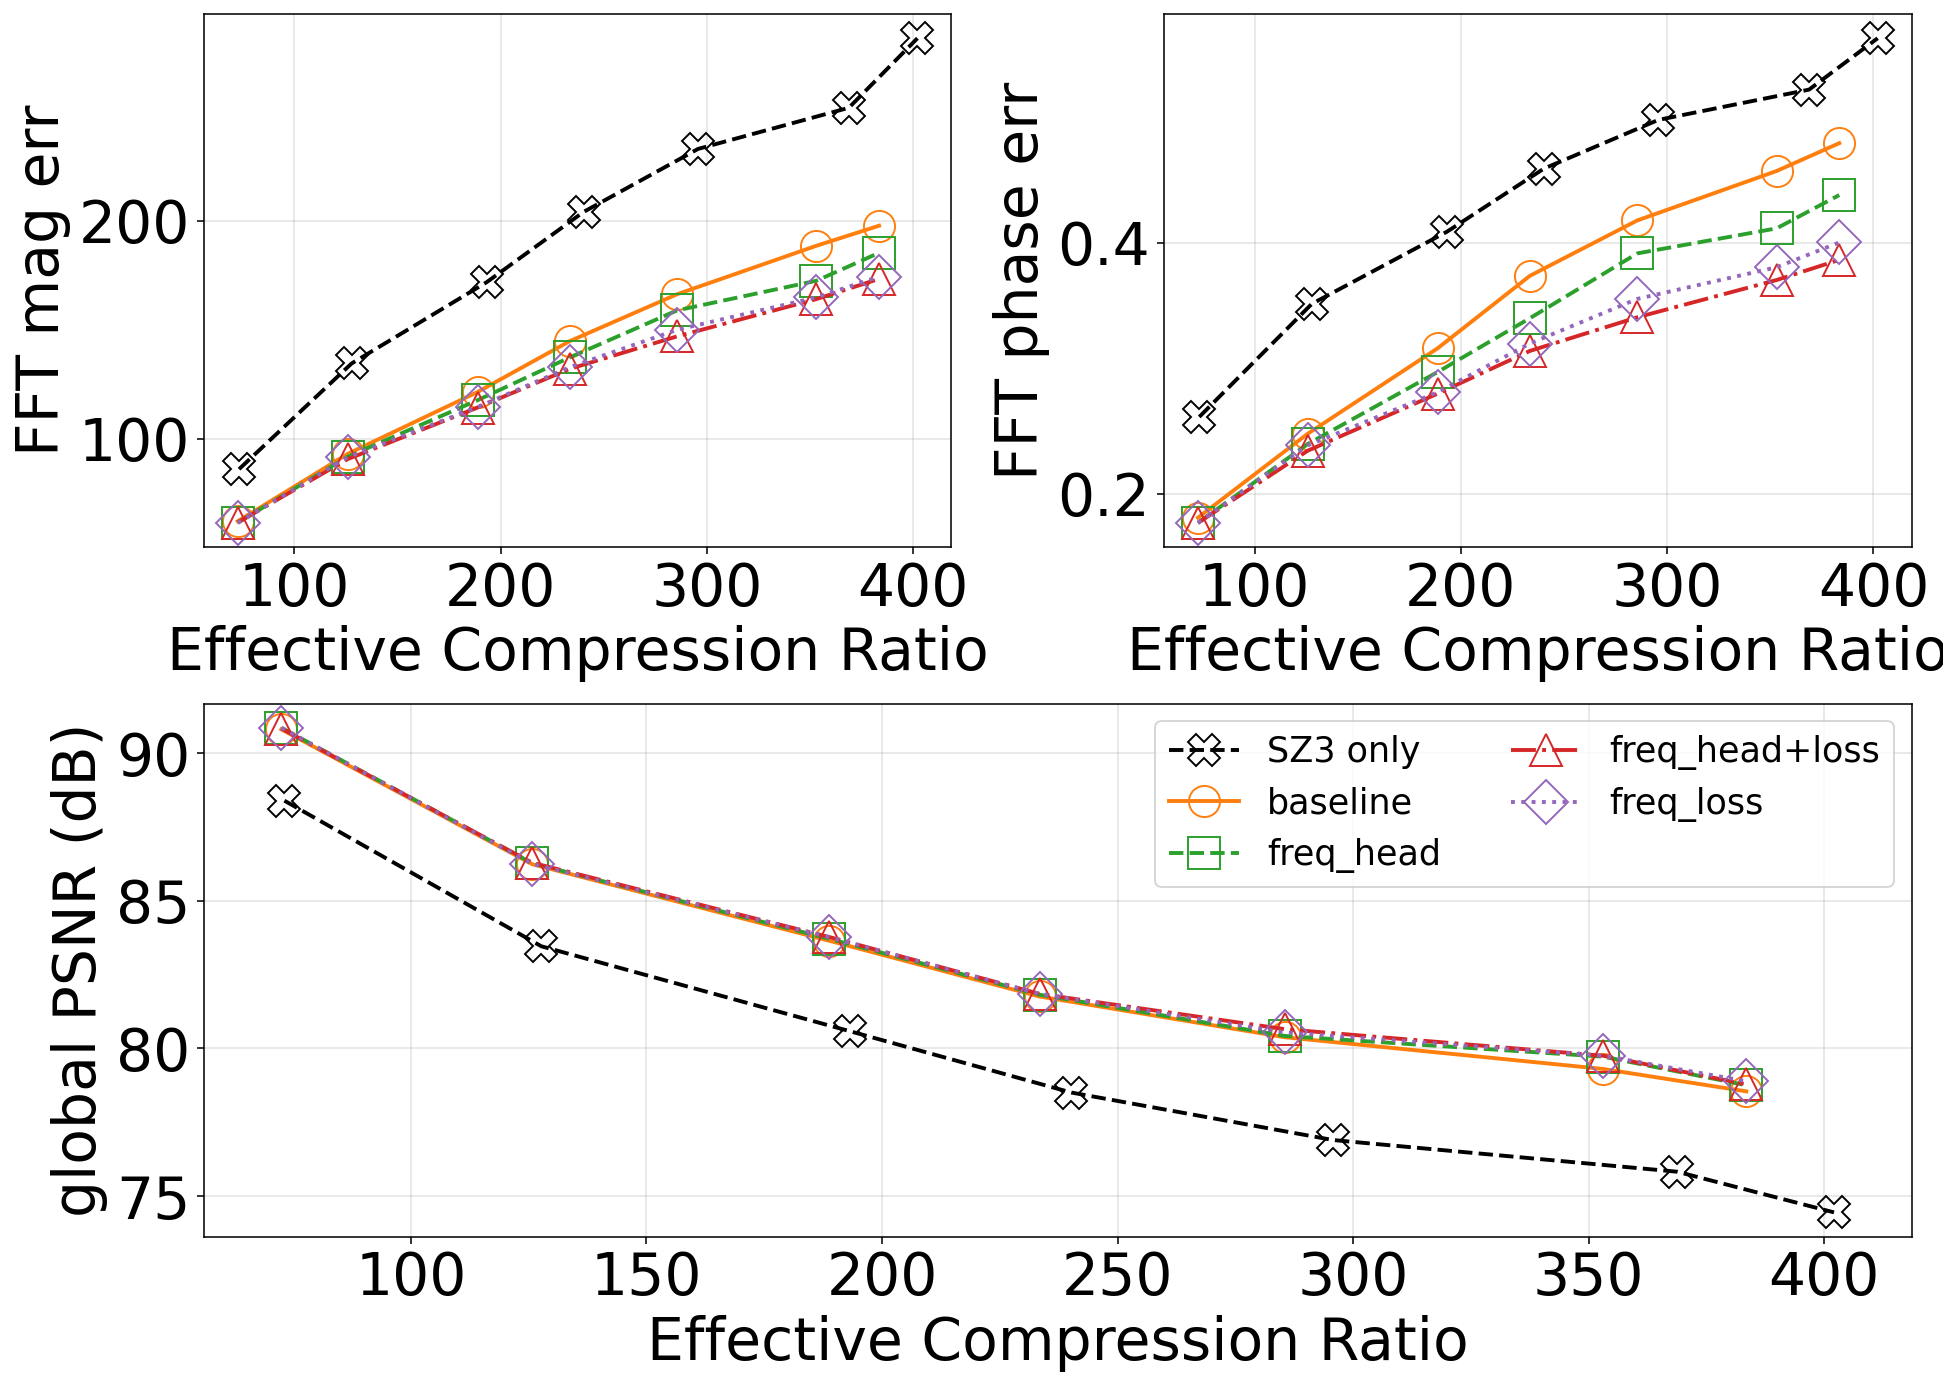

In [6]:
# --- PSNR / FFT err vs effective CR : SZ3 + BG (frequency head / loss ablation) ---
import matplotlib.pyplot as plt
import itertools
import pandas as pd
import numpy as np

PSNR_MODE         = "best"
INCLUDE_AUX_BYTES = bool(globals().get("INCLUDE_AUX_BYTES", False))
NEURLZ_DTYPE_BYTES = int(globals().get("NEURLZ_DTYPE_BYTES", 4))   # NeurLZ model bytes/param
MODEL_DTYPE_BYTES  = int(globals().get("MODEL_DTYPE_BYTES", 2))    # BG model bytes/param (bf16)

x_true = np.asarray(Xs[0], np.float32)
orig   = int(x_true.nbytes)
aux_bytes = int(sum(np.asarray(f, np.float32).nbytes for f in Xs[1:])) if (INCLUDE_AUX_BYTES and len(Xs) > 1) else 0

for r in results_compare:
    patch_sz3_bytes(r)

def _best_metric_row(r):
    logs = [m for m in (r.get("metric_log", []) or [])
            if m.get("psnr") is not None and np.isfinite(float(m["psnr"]))]
    return max(logs, key=lambda m: float(m["psnr"])) if logs else None

rows = []
# 1) SZ3-only baseline
for tag, rel in REL_SETTINGS:
    Xps_rel, _, b = build_Xps_for_rel(float(rel))
    d = _global_diag(Xs[0], np.asarray(Xps_rel[0], np.float32))
    rows.append({"label": "SZ3 only", "rel_err": float(rel),
                 "effective_cr": orig / (float(len(b)) + aux_bytes),
                 "psnr": d["psnr"], "fft_mag_err": d["fft_mag_err"], "fft_phase_err": d["fft_phase_err"]})
                 
# 2) live NeurLZ + BG variants (from results_compare)
for r in results_compare:
    nm  = str(r.get("name", ""))
    rel = float(r.get("rel_err", float("nan")))
    if not np.isfinite(rel):
        continue
    is_neurlz = "NeurLZ" in nm
    sz3_b = float(r.get("sz3_bytes", -1))
    if sz3_b <= 0:
        continue
    nn_b = float(model_param_bytes(r.get("model"),
                                   dtype_bytes=NEURLZ_DTYPE_BYTES if is_neurlz else MODEL_DTYPE_BYTES))
    m = _best_metric_row(r)
    if m is None:
        continue
    label = "NeurLZ" if is_neurlz else str(r.get("ablation_tag") or nm)
    rows.append({"label": label, "rel_err": rel,
                 "effective_cr": orig / (sz3_b + nn_b + aux_bytes),
                 "psnr": float(m["psnr"]),
                 "fft_mag_err": float(m.get("fft_mag_err", np.nan)),
                 "fft_phase_err": float(m.get("fft_phase_err", np.nan))})

df = pd.DataFrame(rows).replace([np.inf, -np.inf], np.nan).dropna(subset=["effective_cr", "psnr"])
if df.empty:
    raise RuntimeError("no rows to plot — run the BG ablation cell first")
best = df.groupby(["label", "rel_err"], as_index=False).agg(
    {"effective_cr": "mean", "psnr": "max", "fft_mag_err": "min", "fft_phase_err": "min"})
display(best.sort_values(["label", "rel_err"]))

# 提取所有的 unique labels
order = (["SZ3 only"] if "SZ3 only" in set(best["label"]) else []) + \
        sorted(l for l in best["label"].unique() if l != "SZ3 only")

# 设置颜色、形状和线型的循环
cmap = plt.get_cmap("tab10")
markers = itertools.cycle(['o', 's', '^', 'D', 'v', 'p', '*', 'h', '<', '>'])
linestyles = itertools.cycle(['-', '--', '-.', ':'])

style_map = {}
for i, lab in enumerate(order):
    if lab == "SZ3 only":
        style_map[lab] = {
            "color": "black", 
            "linestyle": "--", 
            "marker": "X",
            "markersize": 16,         # 设置标记大小 (大一点)
            "markerfacecolor": "none" # 设置表面颜色为空 (空心)
        }
    else:
        style_map[lab] = {
            "color": cmap(i % 10),
            "linestyle": next(linestyles),
            "marker": next(markers),
            "markersize": 16,         # 设置标记大小 (大一点)
            "markerfacecolor": "none" # 设置表面颜色为空 (空心)
        }

# ==========================================
# 定义通用 set_params 函数统一管理字体大小
# ==========================================
def set_params(ax, fontsize=20, tick_fontsize=16):
    """统一设置 Axes 的标签、标题和刻度(ticks)字体大小"""
    ax.xaxis.label.set_fontsize(fontsize)
    ax.yaxis.label.set_fontsize(fontsize)
    ax.title.set_fontsize(fontsize)
    ax.tick_params(axis='both', which='major', labelsize=tick_fontsize)


# --- Plotting 布局配置 (GridSpec) ---
fig = plt.figure(figsize=(14, 10), dpi=140)
gs = fig.add_gridspec(2, 2)

# 上面两张图：FFT Mag err 和 FFT Phase err
ax1 = fig.add_subplot(gs[0, 0]) 
ax2 = fig.add_subplot(gs[0, 1]) 

# 下面一张图：PSNR，横跨两列
ax3 = fig.add_subplot(gs[1, :]) 

for lab in order:
    g = best[best["label"] == lab].sort_values("effective_cr")
    if g.empty:
        continue
    
    sty = style_map[lab]
    
    # 1. Top Left: FFT Mag
    ax1.plot(g["effective_cr"], g["fft_mag_err"], linewidth=2, label=lab, **sty)
    # 2. Top Right: FFT Phase
    ax2.plot(g["effective_cr"], g["fft_phase_err"], linewidth=2, label=lab, **sty)
    # 3. Bottom: PSNR
    ax3.plot(g["effective_cr"], g["psnr"], linewidth=2, label=lab, **sty)

# --- 设置坐标轴和图表细节 ---

# FFT Mag
ax1.set_xlabel("Effective Compression Ratio", fontsize=30)
ax1.set_ylabel("FFT mag err", fontsize=30)
# ax1.set_title(f"FFT magnitude | {TARGET_STEM}")
ax1.grid(True, alpha=0.35)
# ax1.legend(fontsize=12) # 顶部图例较小一点防止遮挡数据
set_params(ax1, fontsize=30, tick_fontsize=30)

# FFT Phase
ax2.set_xlabel("Effective Compression Ratio", fontsize=30)
ax2.set_ylabel("FFT phase err", fontsize=30)
# ax2.set_title(f"FFT phase | {TARGET_STEM}")
ax2.grid(True, alpha=0.35)
set_params(ax2, fontsize=30, tick_fontsize=30)

# PSNR
ax3.set_xlabel("Effective Compression Ratio", fontsize=30)
ax3.set_ylabel(f"global PSNR (dB)", fontsize=30) #{PSNR_MODE.capitalize()} 
# ax3.set_title(f"PSNR vs CR | {TARGET_STEM}")
ax3.grid(True, alpha=0.35)
ax3.legend(fontsize=18, ncol = 2, loc='best') 
set_params(ax3, fontsize=30, tick_fontsize=30)

plt.tight_layout()
save_name = f"fft_err_psnr_vs_cr_{TARGET_STEM}.pdf"
plt.savefig(save_name, format="pdf", bbox_inches="tight")
plt.show()


[Model: spatial] Total Params: 32,410
 [Params] Main (BG) Network : 32,410 parameters
[Init] Epoch   0 | Global PSNR: 88.39 dB | MaxErr: 478.0
[plan] pure_train_budget=30.00s | epochs_cap=20 | steps/epoch=512 | patch=512 | batch=1 | sample=random | data_parallel=False | amp=bf16
[early-stop] DISABLED (cfg.bg_early_stop is False/unset)
[gpu-sampling] 5 fields resident on cuda:0 (~5.4 GB)


/home/sam/Halo_Finder/Final_design/base_script/bg_stage.py:522: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp, dtype=autocast_dtype):


Epoch   1 [BG] | train_wall=1.58s | Loss: 1.421015 | Freq: 1.130478 | Low: 0.076477 | Mid: 0.094202 | High: 0.431921 | Global: 89.63 dB | MaxErr: 955.8  [New Best!]
[timing] first_epoch_pure_train≈1.929s (excludes this epoch's end-of-epoch eval)
Epoch   2 [BG] | train_wall=1.59s | Loss: 1.395036 | Freq: 0.606583 | Low: 0.076739 | Mid: 0.086071 | High: 0.308050 | Global: 90.36 dB | MaxErr: 956.0  [New Best!]
Epoch   3 [BG] | train_wall=1.60s | Loss: 1.239022 | Freq: 0.544796 | Low: 0.075605 | Mid: 0.079512 | High: 0.255663 | Global: 90.61 dB | MaxErr: 956.0  [New Best!]
Epoch   4 [BG] | train_wall=1.58s | Loss: 1.166502 | Freq: 0.508190 | Low: 0.073412 | Mid: 0.075153 | High: 0.234126 | Global: 90.68 dB | MaxErr: 956.0  [New Best!]
Epoch   5 [BG] | train_wall=1.65s | Loss: 1.164207 | Freq: 0.508518 | Low: 0.073170 | Mid: 0.072851 | High: 0.235509 | Global: 90.75 dB | MaxErr: 956.0  [New Best!]
Epoch   6 [BG] | train_wall=1.54s | Loss: 1.127885 | Freq: 0.492275 | Low: 0.071544 | Mid: 0.0

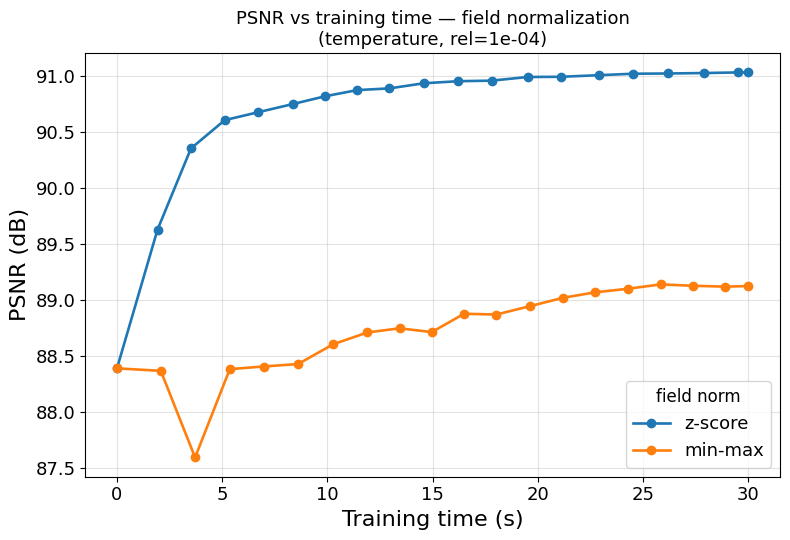

Saved: psnr_vs_time_norm_temperature.pdf
   z-score (   zscore): best PSNR= 91.04 dB | 20 evals | 30.0s train
   min-max ( minmax01): best PSNR= 89.14 dB | 20 evals | 30.0s train


In [7]:
# ── PSNR vs training time : field-normalization ablation (min-max vs z-score) ──
# Same architecture / hyperparameters / SEED; ONLY `bg_field_norm` changes. Each
# variant trains once at a single rel-err bound, and we read the per-epoch
# (time, psnr) trace straight from train_bg_only's history to draw PSNR vs
# wall-clock TRAINING time (eval time excluded). Both curves share the t=0 anchor
# (the SZ3 base PSNR before any training).
import matplotlib.pyplot as plt

NORM_REL_ERR    = float(REL_ERR_SZ_BITSTREAM)                     # SZ3 base bound to train at
NORM_TRAIN_TIME = float(globals().get("NORM_TRAIN_TIME", 30.0))   # s per variant (richer curve)
NORM_VARIANTS   = [
    ("z-score", "zscore",   "tab:blue"),
    ("min-max", "minmax01", "tab:orange"),   # matches normalization.ipynb's [0,1] min-max
]

# train_bg_variant reads the global BG_TRAIN_TIME -> temporarily bump it for a
# longer PSNR-vs-time trace, then restore.
_saved_bg_train_time = BG_TRAIN_TIME
BG_TRAIN_TIME = NORM_TRAIN_TIME
norm_runs = {}
try:
    for label, mode, _color in NORM_VARIANTS:
        set_seed(SEED)
        norm_runs[label] = train_bg_variant(
            tag=f"norm_{mode}", rel_err=NORM_REL_ERR,
            name=f"{label} [{TARGET_STEM}] rel={NORM_REL_ERR:.0e}",
            ablation_panel="norm", ablation_tag=mode,
            bg_field_norm=mode,
        )
finally:
    BG_TRAIN_TIME = _saved_bg_train_time

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5.5))
for label, mode, color in NORM_VARIANTS:
    h    = norm_runs[label]["hist"]
    t    = list(h.get("time", []))
    psnr = [p[1] if isinstance(p, tuple) else p for p in h.get("psnr", [])]
    n    = min(len(t), len(psnr))
    ax.plot(t[:n], psnr[:n], marker="o", markersize=6, linewidth=1.9,
            color=color, label=label)

ax.set_xlabel("Training time (s)", fontsize=16)
ax.set_ylabel("PSNR (dB)", fontsize=16)
ax.set_title(f"PSNR vs training time — field normalization\n"
             f"({TARGET_STEM}, rel={NORM_REL_ERR:.0e})", fontsize=13)
ax.tick_params(labelsize=13)
ax.grid(True, alpha=0.35)
ax.legend(fontsize=13, title="field norm", title_fontsize=12)
plt.tight_layout()
out_pdf = f"psnr_vs_time_norm_{TARGET_STEM}.pdf"
plt.savefig(out_pdf, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", out_pdf)

for label, mode, _color in NORM_VARIANTS:
    h    = norm_runs[label]["hist"]
    psnr = [p[1] if isinstance(p, tuple) else p for p in h.get("psnr", [])]
    tlast = (list(h.get("time", [])) or [0.0])[-1]
    best  = max(psnr) if psnr else float("nan")
    print(f"  {label:>8} ({mode:>9}): best PSNR={best:6.2f} dB | "
          f"{len(psnr)} evals | {tlast:.1f}s train")


[lambda sweep] baryon_density rel=6e-05 | SZ3 base 101.78 dB | CR 1700.9x | freq_weight=0.5

[Model: spatial] Total Params: 29,803
 [Params] Main (BG) Network : 29,803 parameters
[Init] Epoch   0 | Global PSNR: 101.78 dB | MaxErr: 7.0
[plan] pure_train_budget=100.00s | epochs_cap=20 | steps/epoch=512 | patch=512 | batch=1 | sample=random | data_parallel=False | amp=bf16
[early-stop] DISABLED (cfg.bg_early_stop is False/unset)
[gpu-sampling] 6 fields resident on cuda:0 (~6.4 GB)


/home/sam/Halo_Finder/Final_design/base_script/bg_stage.py:522: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp, dtype=autocast_dtype):


Epoch   1 [BG] | train_wall=3.43s | Loss: 0.477033 | Freq: 0.027145 | Low: 0.124249 | Mid: 0.046674 | High: 0.086246 | Global: 109.99 dB | MaxErr: 13.9  [New Best!]
[timing] first_epoch_pure_train≈3.853s (excludes this epoch's end-of-epoch eval)
Epoch   2 [BG] | train_wall=1.47s | Loss: 0.244737 | Freq: 0.016348 | Low: 0.025697 | Mid: 0.017102 | High: 0.072639 | Global: 110.49 dB | MaxErr: 13.6  [New Best!]
Epoch   3 [BG] | train_wall=1.37s | Loss: 0.205805 | Freq: 0.013373 | Low: 0.019351 | Mid: 0.013177 | High: 0.065053 | Global: 111.79 dB | MaxErr: 13.7  [New Best!]
Epoch   4 [BG] | train_wall=1.37s | Loss: 0.153912 | Freq: 0.008867 | Low: 0.014993 | Mid: 0.010495 | High: 0.049502 | Global: 112.29 dB | MaxErr: 13.7  [New Best!]
Epoch   5 [BG] | train_wall=1.37s | Loss: 0.162080 | Freq: 0.009156 | Low: 0.018287 | Mid: 0.011310 | High: 0.049974 | Global: 112.84 dB | MaxErr: 13.5  [New Best!]
Epoch   6 [BG] | train_wall=1.38s | Loss: 0.131711 | Freq: 0.006777 | Low: 0.015652 | Mid: 0.0

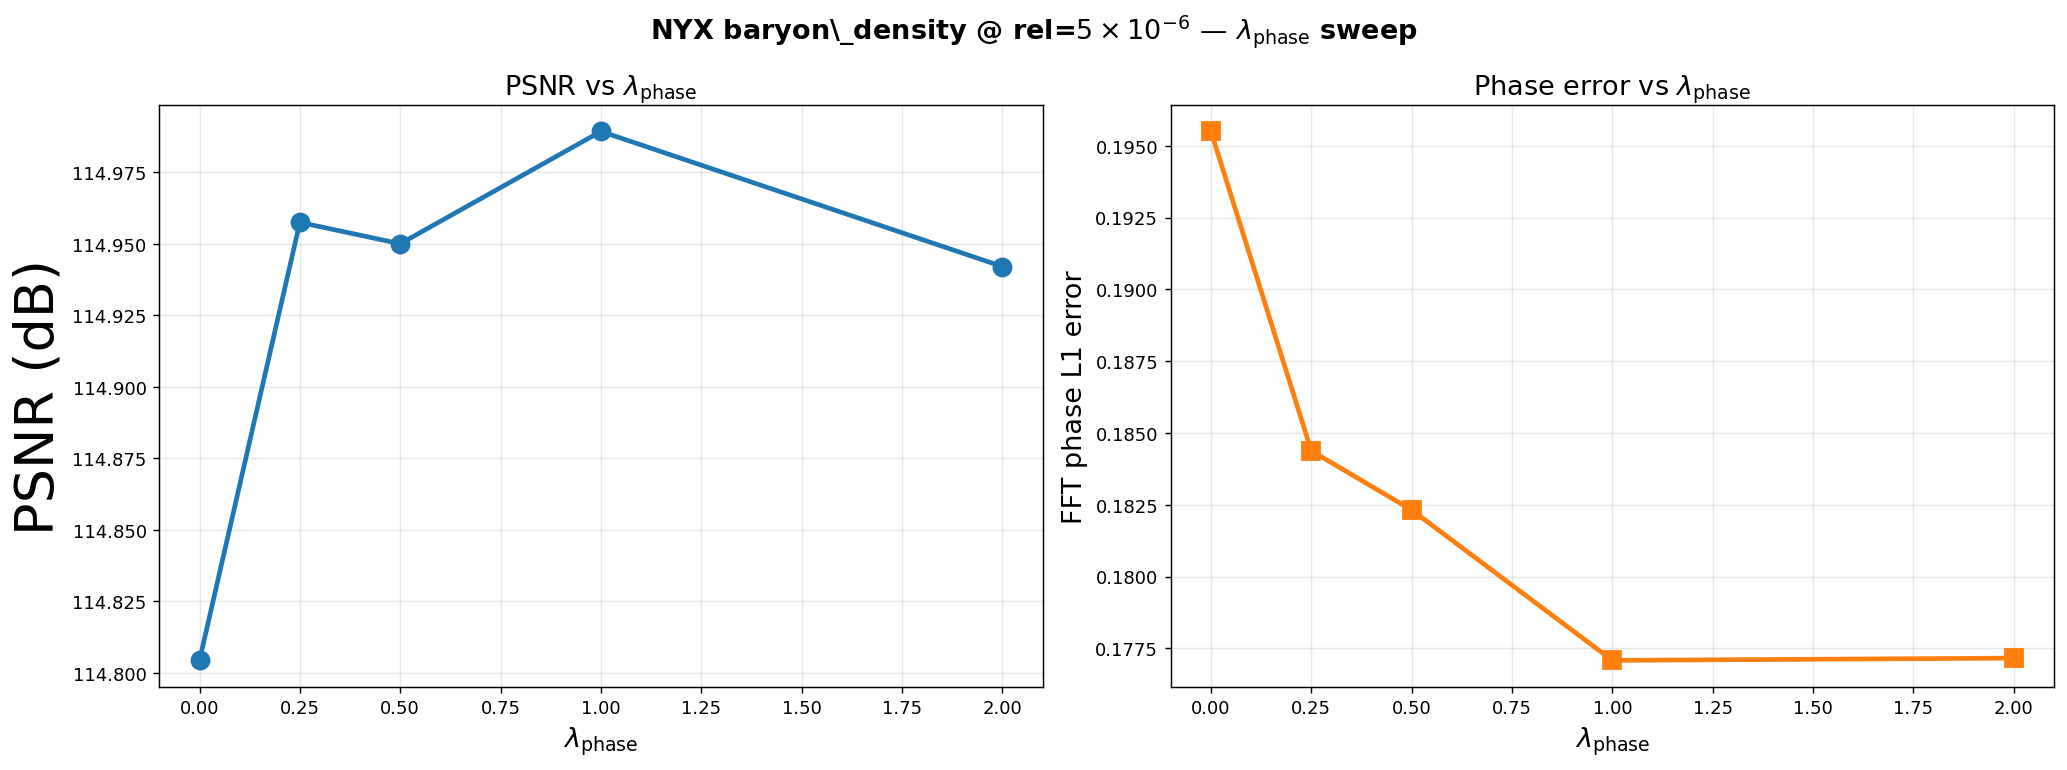

Saved: lambda_phase_sweep_nyx_baryon.pdf


In [8]:
# ── lambda_phase sweep: NYX baryon_density @ rel=5e-6 ─────────────────────────
# Self-contained: loads baryon_density + aux itself, fixes bg_freq_weight and the
# three-band split, and sweeps ONLY bg_fft_phase_weight (= lambda_phase). Records
# final PSNR and FFT phase L1 error. Same model as the freq ablation (bg_h=22, 20 ep).
import sys, numpy as np, pandas as pd, matplotlib.pyplot as plt
if "/home/sam/Data_Compression/SZ3/tools/pysz" not in sys.path:
    sys.path.append("/home/sam/Data_Compression/SZ3/tools/pysz")
from pysz import SZ

NYX_DIR   = "/home/sam/Halo_Finder/halo_finder_v1/SDRBENCH-EXASKY-NYX-512x512x512/origin/"
NYX_SHAPE = (512, 512, 512)
NYX_ALL   = ["baryon_density", "dark_matter_density", "temperature",
             "velocity_x", "velocity_y", "velocity_z"]
LP_TARGET, LP_REL   = "baryon_density", 6e-5
LP_FREQ_WEIGHT      = 0.5                      # held fixed
LAMBDA_PHASE_SWEEP  = [0.0, 0.25, 0.5, 1.0, 2.0]

_tgt = np.fromfile(NYX_DIR + LP_TARGET + ".f32", np.float32).reshape(NYX_SHAPE)
_aux = [np.memmap(NYX_DIR + a + ".f32", np.float32, mode="r", shape=NYX_SHAPE)
        for a in NYX_ALL if a != LP_TARGET]
_sz  = SZ("/home/sam/Data_Compression/SZ3/build/lib64/libSZ3c.so")
_b, _ = _sz.compress(_tgt, 1, 0, float(LP_REL), 0)
_lq  = np.ascontiguousarray(_sz.decompress(_b, _tgt.shape, np.float32), np.float32)
_Xs, _Xps = [_tgt] + _aux, [_lq] + _aux
print(f"[lambda sweep] {LP_TARGET} rel={LP_REL:.0e} | SZ3 base "
      f"{_global_diag(_tgt, _lq)['psnr']:.2f} dB | CR {_tgt.nbytes/len(_b):.1f}x | "
      f"freq_weight={LP_FREQ_WEIGHT}")

def _train_lambda(lp):
    cfg = build_bg_only_cfg(
        X_target=_Xs[0], Xps=_Xps, max_train_time=100.0, bg_h=21, roi_h=4,
        epochs=20, steps_per_epoch=512, bg_patch_size=512, bg_batch=1, lr=1e-3,
        bg_field_norm="zscore", bg_freq_weight=LP_FREQ_WEIGHT,
        bg_fft_phase_weight=float(lp), bg_freq_warmup_epochs=1)
    cfg.bg_arch = "spatial"; cfg.bg_split_mode = "three"; cfg.bg_split_bands = True
    cfg.bg_split_sigma = 0.12; cfg.bg_sigma_low = 0.08; cfg.bg_sigma_mid = 0.18
    cfg.bg_low_weight = 0.25; cfg.bg_mid_weight = 0.55; cfg.bg_high_weight = 1.10
    cfg.bg_cr_rel_err = float(LP_REL); cfg.seed = SEED
    def _ev(m, c=cfg):
        d = _global_diag(_Xs[0], run_bg_inference(m, _Xs, _Xps, c, float(LP_REL)))
        return d["psnr"], d["max_err"]
    set_seed(SEED)
    model, _ = train_bg_only(Xs=_Xs, Xps=_Xps, device=device, cfg=cfg, evaluator=_ev)
    d = _global_diag(_Xs[0], run_bg_inference(model, _Xs, _Xps, cfg, float(LP_REL)))
    del model
    torch.cuda.empty_cache() if torch.cuda.is_available() else None
    return d

_rows = []
for lp in LAMBDA_PHASE_SWEEP:
    d = _train_lambda(lp)
    _rows.append({"lambda_phase": lp, "PSNR": d["psnr"],
                  "fft_phase_err": d["fft_phase_err"], "fft_mag_err": d["fft_mag_err"]})
    print(f"  lambda_phase={lp:.2f} -> PSNR {d['psnr']:.3f} dB | "
          f"phase_err {d['fft_phase_err']:.3e} | mag_err {d['fft_mag_err']:.3e}")
lam_df = pd.DataFrame(_rows)
print("\n" + lam_df.to_string(index=False))
_base_p = lam_df["PSNR"].max()
print(f"\nPSNR spread across lambda_phase: {lam_df['PSNR'].max() - lam_df['PSNR'].min():.3f} dB")

fig, ax = plt.subplots(1, 2, figsize=(16, 6), dpi=130)
ax[0].plot(lam_df["lambda_phase"], lam_df["PSNR"], "-o", color="#1f77b4", lw=2.6, ms=10)
ax[0].set_xlabel(r"$\lambda_{\mathrm{phase}}$", fontsize=15)
ax[0].set_ylabel("PSNR (dB)", fontsize=30)
ax[0].set_title(r"PSNR vs $\lambda_{\mathrm{phase}}$", fontsize=15); ax[0].grid(True, alpha=0.3)
ax[1].plot(lam_df["lambda_phase"], lam_df["fft_phase_err"], "-s", color="#ff7f0e", lw=2.6, ms=10)
ax[1].set_xlabel(r"$\lambda_{\mathrm{phase}}$", fontsize=15)
ax[1].set_ylabel("FFT phase L1 error", fontsize=15)
ax[1].set_title(r"Phase error vs $\lambda_{\mathrm{phase}}$", fontsize=15); ax[1].grid(True, alpha=0.3)
fig.suptitle(r"NYX baryon\_density @ rel=$5\times10^{-6}$ — $\lambda_{\mathrm{phase}}$ sweep",
             fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("lambda_phase_sweep_nyx_baryon.pdf", bbox_inches="tight")
plt.show()
print("Saved: lambda_phase_sweep_nyx_baryon.pdf")


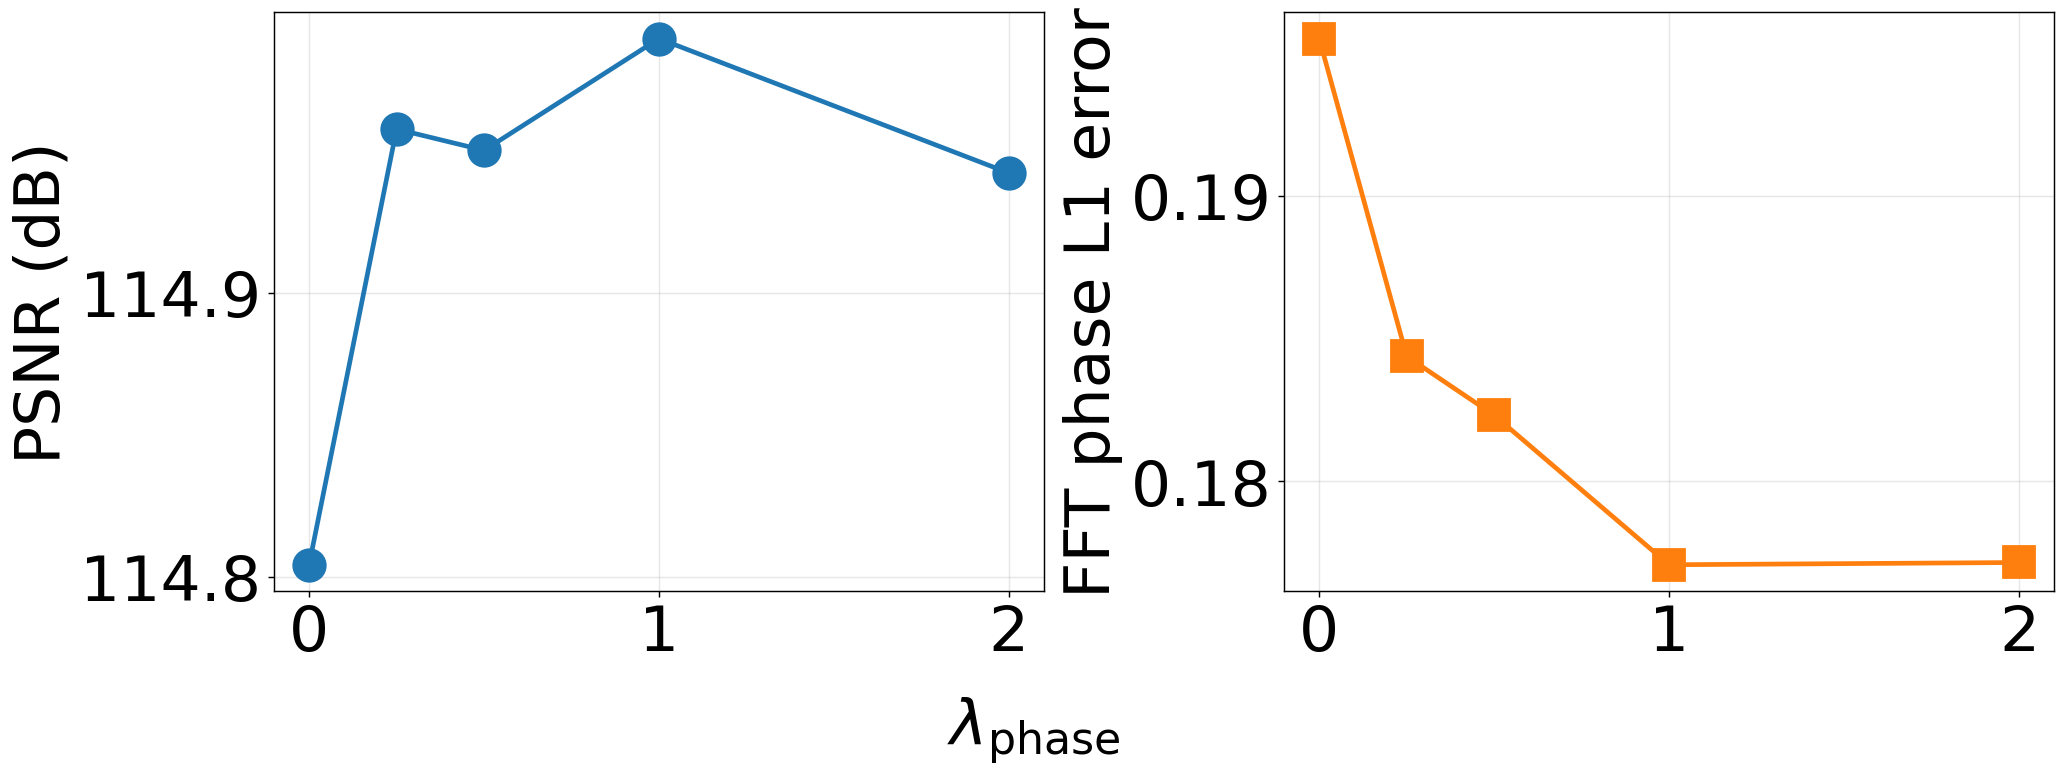

Saved: lambda_phase_sweep_nyx_baryon.pdf


In [17]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6), dpi=130)
ax[0].plot(lam_df["lambda_phase"], lam_df["PSNR"], "-o", color="#1f77b4", lw=2.6, ms=18)
# 【改动 1】：注释掉独立的 X 轴标签
# ax[0].set_xlabel(r"$\lambda_{\mathrm{phase}}$", fontsize=30)
ax[0].set_ylabel("PSNR (dB)", fontsize=35)
ax[0].grid(True, alpha=0.3) # ax[0].set_title(r"PSNR vs $\lambda_{\mathrm{phase}}$", fontsize=30); 
ax[0].tick_params(labelsize=35) 

ax[1].plot(lam_df["lambda_phase"], lam_df["fft_phase_err"], "-s", color="#ff7f0e", lw=2.6, ms=18)
# 【改动 2】：注释掉独立的 X 轴标签
# ax[1].set_xlabel(r"$\lambda_{\mathrm{phase}}$", fontsize=30)
ax[1].set_ylabel("FFT phase L1 error", fontsize=35)
ax[1].grid(True, alpha=0.3)
ax[1].tick_params(labelsize=35) 

# ax[1].set_title(r"Phase error vs $\lambda_{\mathrm{phase}}$", fontsize=15)
# fig.suptitle(r"NYX baryon\_density @ rel=$5\times10^{-6}$ — $\lambda_{\mathrm{phase}}$ sweep",
#              fontsize=15, fontweight="bold")

# 【改动 3】：添加全局共享的 X 轴标签（可以加个 y 参数微调位置避免太挤，比如 y=-0.05，不需要的话删掉 y 即可）
fig.supxlabel(r"$\lambda_{\mathrm{phase}}$", fontsize=35)

plt.tight_layout()
plt.savefig("lambda_phase_sweep_nyx_baryon.pdf", bbox_inches="tight")
plt.show()
print("Saved: lambda_phase_sweep_nyx_baryon.pdf")
